In [8]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, Normalizer, RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, LassoCV, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score




pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv('Data_Modelisation-3.csv')
df = df[~(df["Contaminant"].isin(["DRY"]))]
df = df.drop(['Moyenne CFL F',"hauteur (mm)",'Fv (kg)','Tsurf (C)'], axis=1)
df.Vitesse = df.Vitesse.astype(str)

In [10]:
df.shape

(1033, 6)

In [11]:
X_o = df.drop('Glissement',axis = 1).copy()
#X_o["descritisation"] = X_o['Moyenne G% [%]'].apply(descritisation)
#y = df['Moyenne CFL C']

### Analyse par chaque contaminant:

In [12]:
# Neige fraiche (B)
nfb = X_o[X_o.Contaminant == 'Neige fraiche (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Neige fraiche (G)
nfg = X_o[X_o.Contaminant == 'Neige fraiche (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (G)
ncg = X_o[X_o.Contaminant == 'N.C. (G)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# N.C. (B)
ncb = X_o[X_o.Contaminant == 'N.C. (B)'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# NC.C.
ncc = X_o[X_o.Contaminant == 'NC.C.'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Verglas
ver = X_o[X_o.Contaminant == 'Verglas'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Glace
gla = X_o[X_o.Contaminant == 'Glace'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# SLUSH
slh = X_o[X_o.Contaminant == 'SLUSH'].drop('Contaminant', axis = 1).copy().reset_index(drop = True)
# Columns to drop in every modele


In [13]:
l=[nfb, nfg, ncg, ncb, ncc, ver,  gla, slh]
names = ['nfb', 'nfg', 'ncg', 'ncb', 'ncc', 'ver',  'gla', 'slh']
Contaminant = ['Neige fraiche (B)', 'Neige fraiche (G)', 'N.C. (G)', 'N.C. (B)', 'NC.C.', 'Verglas', 'Glace', 'SLUSH']
dict = {"Contaminant" : Contaminant, "Nombre d'observation" : list(map(lambda x: x.shape[0], l))}
pd.DataFrame(dict).sort_values(["Nombre d'observation"], ascending = False).reset_index(drop = True)

,Contaminant,Nombre d'observation
0,NC.C.,232
1,Neige fraiche (B),191
2,N.C. (B),140
3,Neige fraiche (G),129
4,Glace,107
5,N.C. (G),106
6,SLUSH,70
7,Verglas,58


## Data Preprocessing

In [14]:
def scale_encode(x,y = 0):
    encoder = OneHotEncoder(drop='first')
    # Séparer les variables qualitatives et numériques
    qualitative_vars = ['Vitesse']
    numeric_vars = x.select_dtypes(include=['float']).columns.tolist()
    
    # Appliquer le one-hot encoding aux variables qualitatives
    encoded_vars = encoder.fit_transform(x[qualitative_vars]).toarray()
    encoded_columns = encoder.get_feature_names_out(qualitative_vars)
    encoded_df = pd.DataFrame(encoded_vars, columns=encoded_columns)
    if y == 1:  # Appliquer le StandardScaler aux variables numériques
        scaler = StandardScaler().set_output(transform='pandas')
    elif y == 2:  # Appliquer le Normalizer aux variables numériques
        scaler = Normalizer().set_output(transform='pandas')
    else:
        X = pd.concat([x.drop(['Vitesse'], axis=1), encoded_df], axis=1)
        return X
    
    # Appliquer le scaler et transformer les variables numériques
    scaled_df = scaler.fit_transform(x[numeric_vars])
    
    # Concaténation des DataFrames encodé et standardisé
    X = pd.concat([scaled_df, encoded_df], axis=1)
    return X
#Fonction utile
def coef(X, regressor):
    y_pred = regressor.predict(X_test)
    y_pred_train = regressor.predict(X_train)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = (y_test-y_pred).abs().mean()
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    mae_train = (y_train-y_pred_train).abs().mean()
    
    
    
    print(f"Pour le test: RMSE = {round((np.sqrt(mse)),5)}, R² = {round(r2*100,2)}, MAE = {round(mae,5)}")
    print(f"Pour le train: RMSE = {round((np.sqrt(mse_train)),5)}, R² = {round(r2_train*100,2)}, MAE = {round(mae_train,5)}")
    coefficients = regressor.coef_
    intercept = regressor.intercept_
    features = X.columns
    
    coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})
    coef_df['Coefficient'] = coef_df['Coefficient'].apply(lambda x: f"{x:.6f}")
    
    print(coef_df)
    print(f"Intercept: {intercept:.4f}")

In [15]:
# Bla bla bla
one_hot_encoder = OneHotEncoder(sparse=False).set_output(transform='pandas')
encoded_df = one_hot_encoder.fit_transform(df[['Vitesse']])

#print(encoded_df)

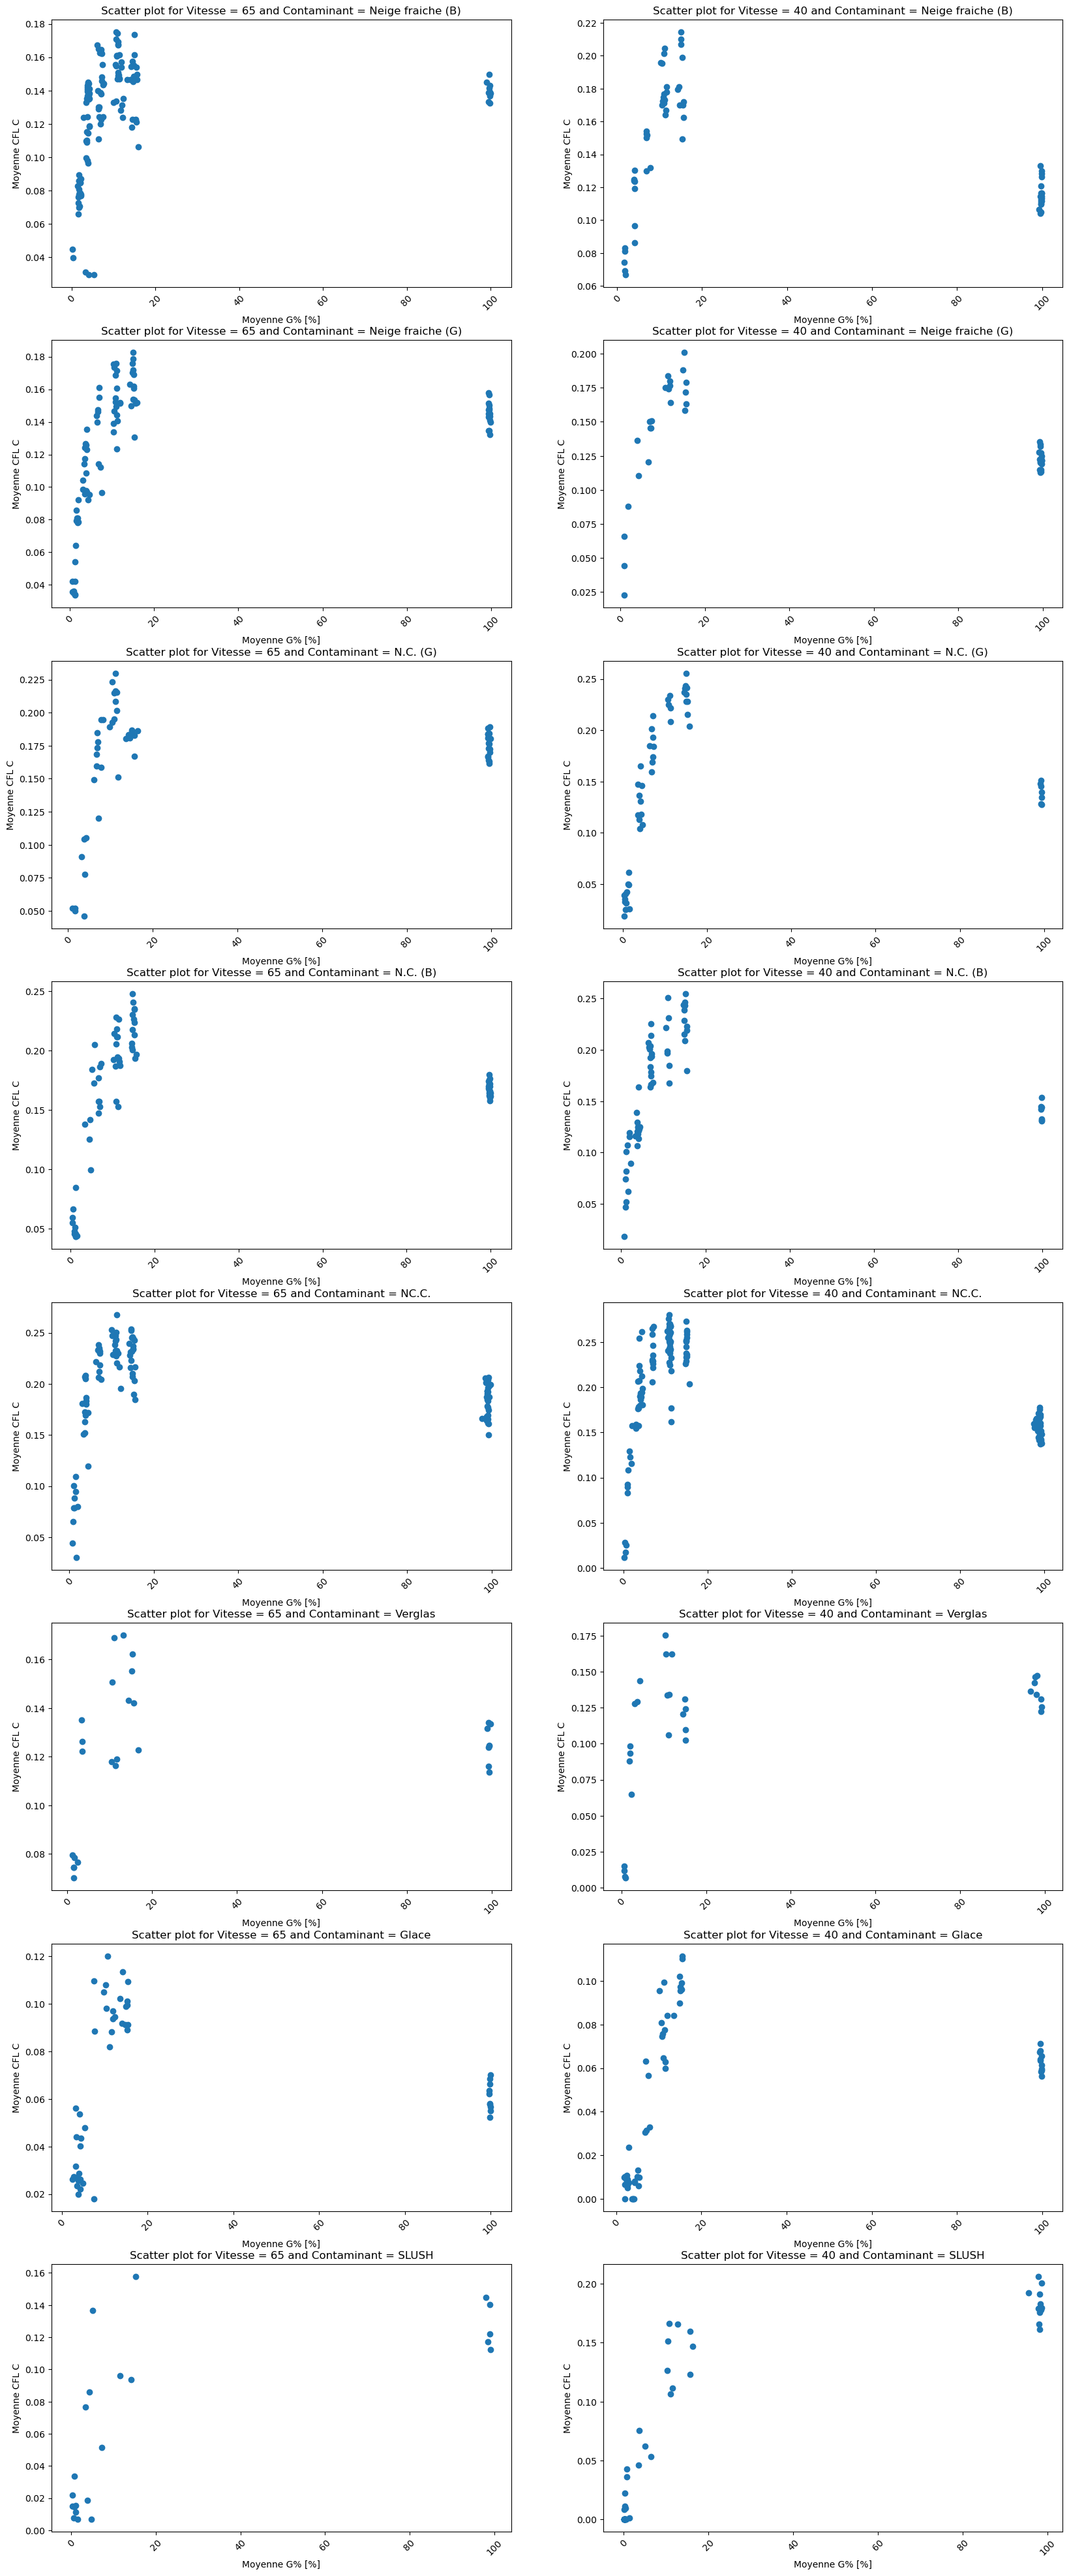

In [16]:
a=1
plt.figure(figsize=(20, 50))
for i in df.Contaminant.unique():
    
    v = "65"
    c = i
    
    plt.subplot(df.Contaminant.unique().shape[0],2,a)
    x_data = df[(df.Vitesse == v) & (df.Contaminant == i)]["Moyenne G% [%]"]
    y_data = df[(df.Vitesse == v) & (df.Contaminant == c)]["Moyenne CFL C"]
    plt.scatter(x_data, y_data)
    plt.xlabel("Moyenne G% [%]")
    plt.ylabel("Moyenne CFL C")
    plt.title(f"Scatter plot for Vitesse = {v} and Contaminant = {c}")
    
    # Optionnel: définir les graduations de l'axe des x
    plt.xticks(rotation=45)  # Exemple : rotation des graduations pour une meilleure lisibilité
    v = "40"
    plt.subplot(df.Contaminant.unique().shape[0],2,a+1)
    x_data = df[(df.Vitesse == v) & (df.Contaminant == i)]["Moyenne G% [%]"]
    y_data = df[(df.Vitesse == v) & (df.Contaminant == c)]["Moyenne CFL C"]
    plt.scatter(x_data, y_data)
    plt.xlabel("Moyenne G% [%]")
    plt.ylabel("Moyenne CFL C")
    plt.title(f"Scatter plot for Vitesse = {v} and Contaminant = {c}")
    
    # Optionnel: définir les graduations de l'axe des x
    plt.xticks(rotation=45)  # Exemple : rotation des graduations pour une meilleure lisibilité
    
    a+=2
plt.show()

## Neige fraiche (B) (173 observations)

Les physiciens soutiennent que la masse, la température de surface et celle de la bande de roulement n'ont pas un impact significatif sur la variation du CFL C.  
En outre, d'apres les trois graphes précedents, on peut ajouter que ces trois variables présentent une faible variabilité pour ce contaminant. Par conséquent, les inclure dans un modèle, notamment de régression linéaire, rendrait celui-ci plus complexe et augmenterait le risque de surapprentissage.

In [17]:
def descritisation_nfb(x):
    if x< 6:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

In [18]:
X = nfb.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfb)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)


X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']




y= nfb['Moyenne CFL C']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=2)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
coef(X, regressor)

Pour le test: RMSE = 0.01733, R² = 69.59, MAE = 0.01416
Pour le train: RMSE = 0.0219, R² = 63.51, MAE = 0.01525
          Feature Coefficient
0  Moyenne G% [%]   -0.001165
1          log(g)    0.041343
2      Vitesse_65   -0.019557
3              g2   -0.000004
4             g*V    0.000407
Intercept: 0.0798


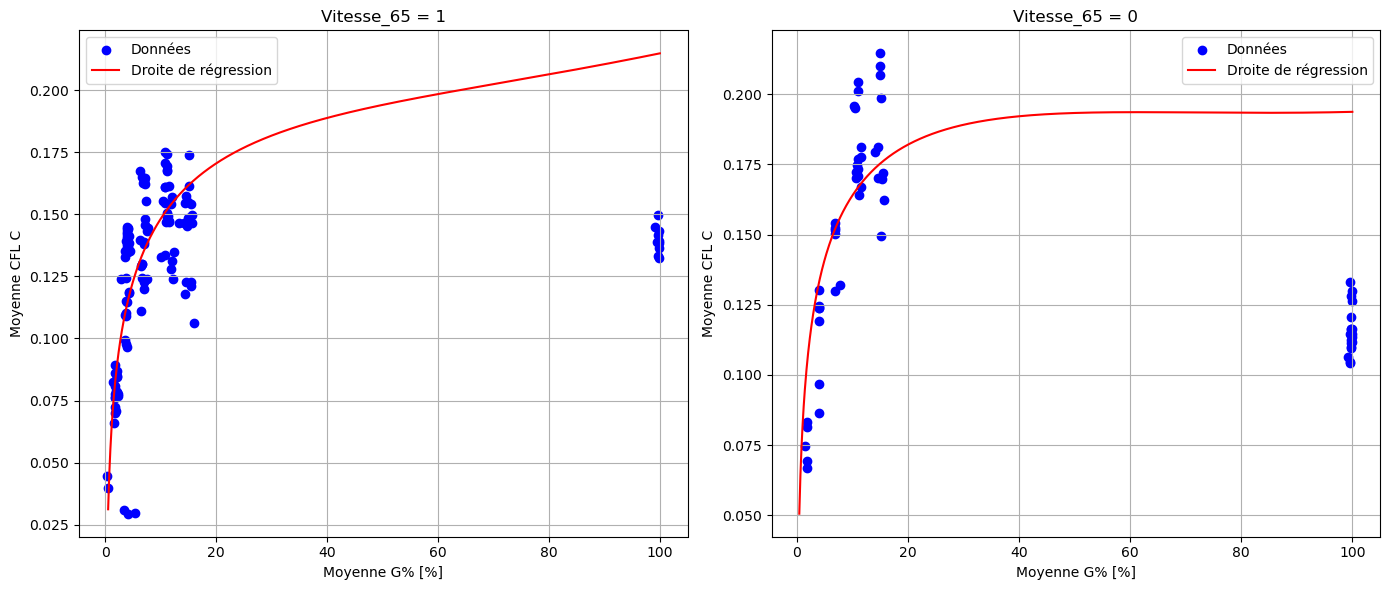

In [19]:
# Coefficients de la régression
intercept = 0.0798


coefficients = {
    'Moyenne G% [%]': -0.001165,
    'log(g)':0.041343,
    'Vitesse_65': -0.019557,
    'g2': 0.000004,
    'g*V': 0.000407
}

# Préparation des données
X = nfb.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 1))

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 0))

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## Neige fraiche (G) (129 observations)

In [20]:
def descritisation_nfg(x):
    if x<3:
        return "3"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

In [21]:
X = nfg.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_nfg)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


y= nfg['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = stratify_combined, random_state=20)#7 20 29 70 84 555
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)


Pour le test: RMSE = 0.00968, R² = 94.2, MAE = 0.00794
Pour le train: RMSE = 0.01402, R² = 86.34, MAE = 0.01117
          Feature Coefficient
0  Moyenne G% [%]   -0.001771
1          log(g)    0.050308
2      Vitesse_65   -0.017053
3              g2    0.000000
4             g*V    0.000387
Intercept: 0.0645


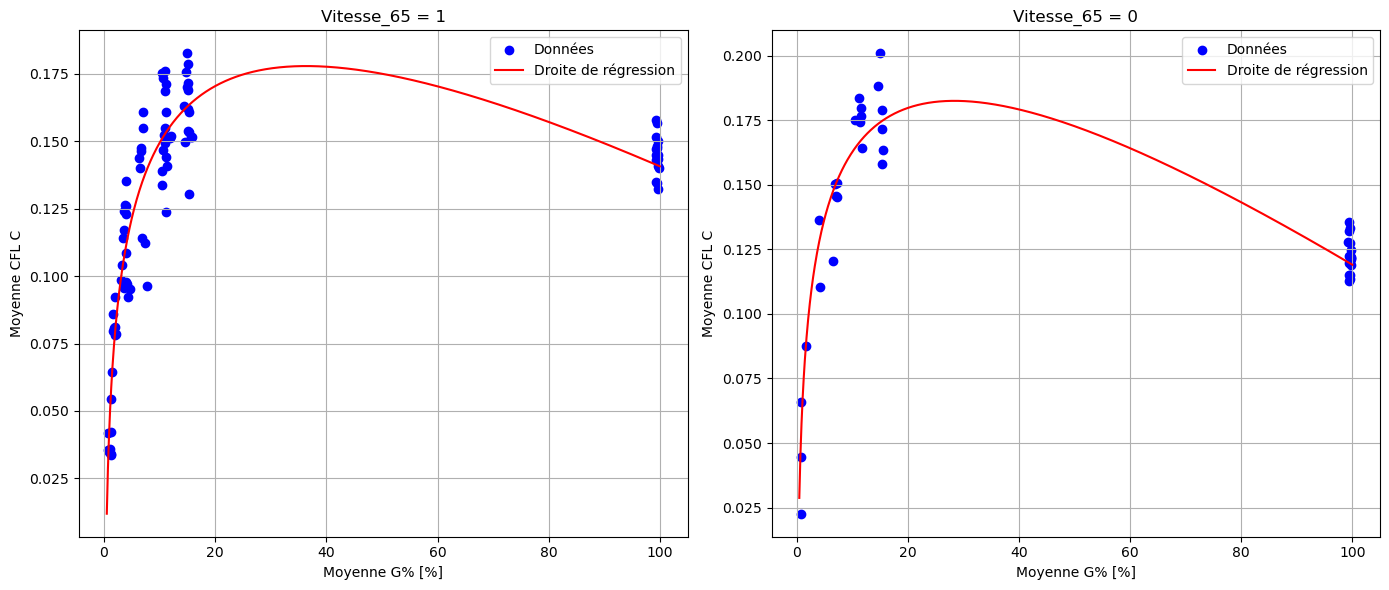

In [22]:
# Coefficients de la régression
intercept = 0.0645

coefficients = {
    'Moyenne G% [%]': -0.001771,
    'log(g)': 0.050308,
    'Vitesse_65': -0.017053,
    'g2': 0.000000,
    'g*V':0.000387
}

# Préparation des données
X = nfg.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 1))

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 0))

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## N.C. (G) (111 observations)

In [23]:
def descritisation_ncg(x):
    if x<2:
        return "2"
    elif x< 5:
        return "5"
    elif x< 9:
        return "9"
    elif x< 12:
        return "12"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [24]:
X = ncg.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncg)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']


stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


y= ncg['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=70)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.02447, R² = 83.14, MAE = 0.02017
Pour le train: RMSE = 0.02134, R² = 87.55, MAE = 0.01694
          Feature Coefficient
0  Moyenne G% [%]    0.002808
1          log(g)    0.053883
2      Vitesse_65   -0.031678
3              g2   -0.000045
4             g*V    0.000670
Intercept: 0.0557


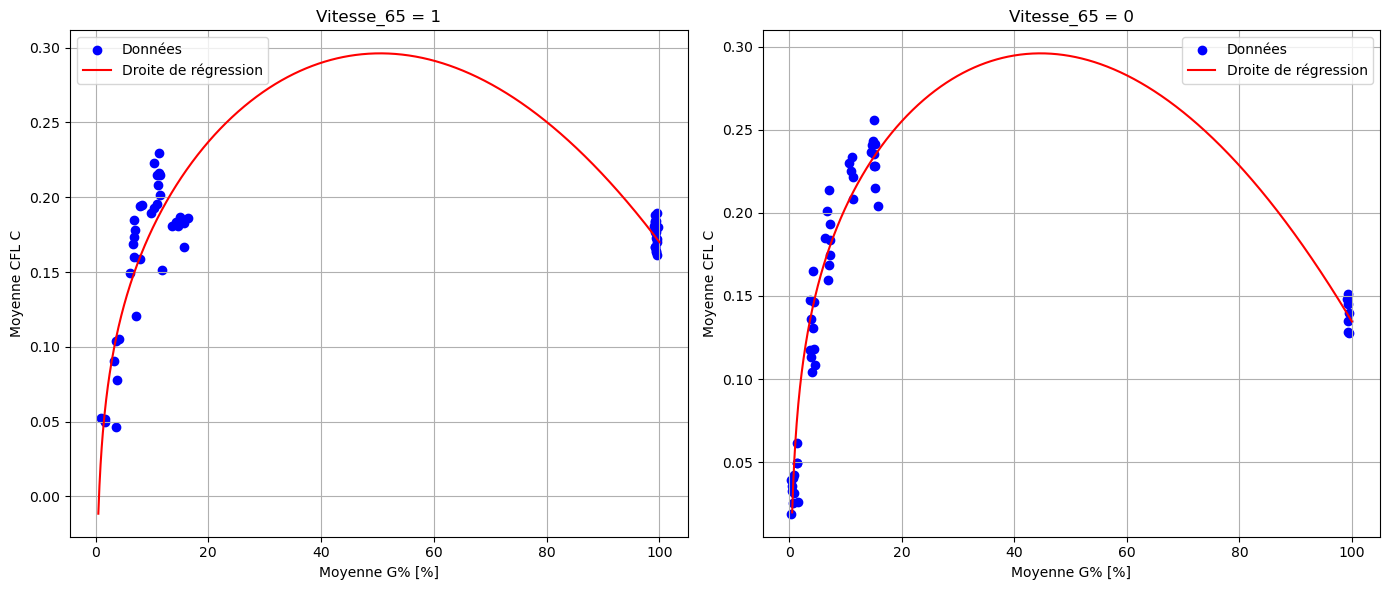

In [25]:
# Coefficients de la régression
intercept = 0.0557


coefficients = {
    'Moyenne G% [%]': 0.002808,
    'log(g)': 0.053883,
    'Vitesse_65': -0.031678,
    'g2': -0.000045,
    'g*V': 0.000670
}

# Préparation des données
X = ncg.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 1))

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 0))

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## N.C. (B) (141 observations)

In [29]:
def descritisation_ncb(x):
    if x<2:
        return "2"
    elif x< 6:
        return "6"
    elif x< 9:
        return "9"
    elif x< 13:
        return "13"
    elif x< 16:
        return "16"
    else:
        return "more"

In [30]:
X = ncb.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncb)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)


y= ncb['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=51)#3 15 51 62 96
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.01636, R² = 90.63, MAE = 0.01403
Pour le train: RMSE = 0.02105, R² = 85.6, MAE = 0.01691
          Feature Coefficient
0  Moyenne G% [%]    0.003059
1          log(g)    0.046876
2      Vitesse_65   -0.010259
3              g2   -0.000045
4             g*V    0.000365
Intercept: 0.0659


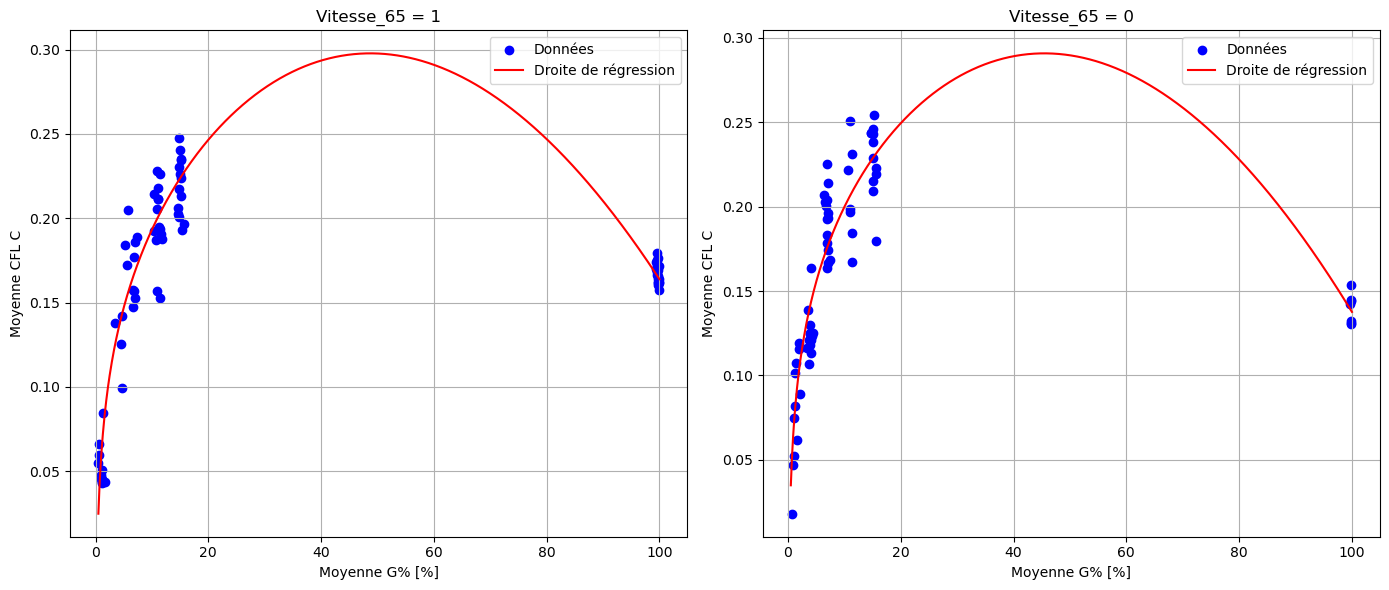

In [28]:
# Coefficients de la régression
intercept =  0.0659
coefficients = {
    'Moyenne G% [%]': 0.003059,
    'log(g)': 0.046876,
    'Vitesse_65': -0.010259,
    'g2': -0.000045,
    'g*V': 0.000365
}

# Préparation des données
X = ncb.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 1))

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 0))

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## NC.C. (238 observations)

In [31]:
def descritisation_ncc(x):
    if x<2:
        return "2"
    if x<4:
        return "4"
    if x<6:
        return "6"
    elif x< 8:
        return "8"
    elif x< 11:
        return "11"
    elif x< 14:
        return "14"
    elif x< 16:
        return "16"
    else:
        return "more"

In [32]:
X = ncc.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_ncc)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
# X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']
#X["g3"] = X['Moyenne G% [%]']**3
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']

stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)



y= ncc['Moyenne CFL C']    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=16)#16 55 64 70 81
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.01543, R² = 92.56, MAE = 0.01247
Pour le train: RMSE = 0.02186, R² = 82.87, MAE = 0.01609
          Feature Coefficient
0  Moyenne G% [%]   -0.007322
1          log(g)    0.091357
2      Vitesse_65   -0.024123
3              g2    0.000037
4             g*V    0.000500
Intercept: 0.1024


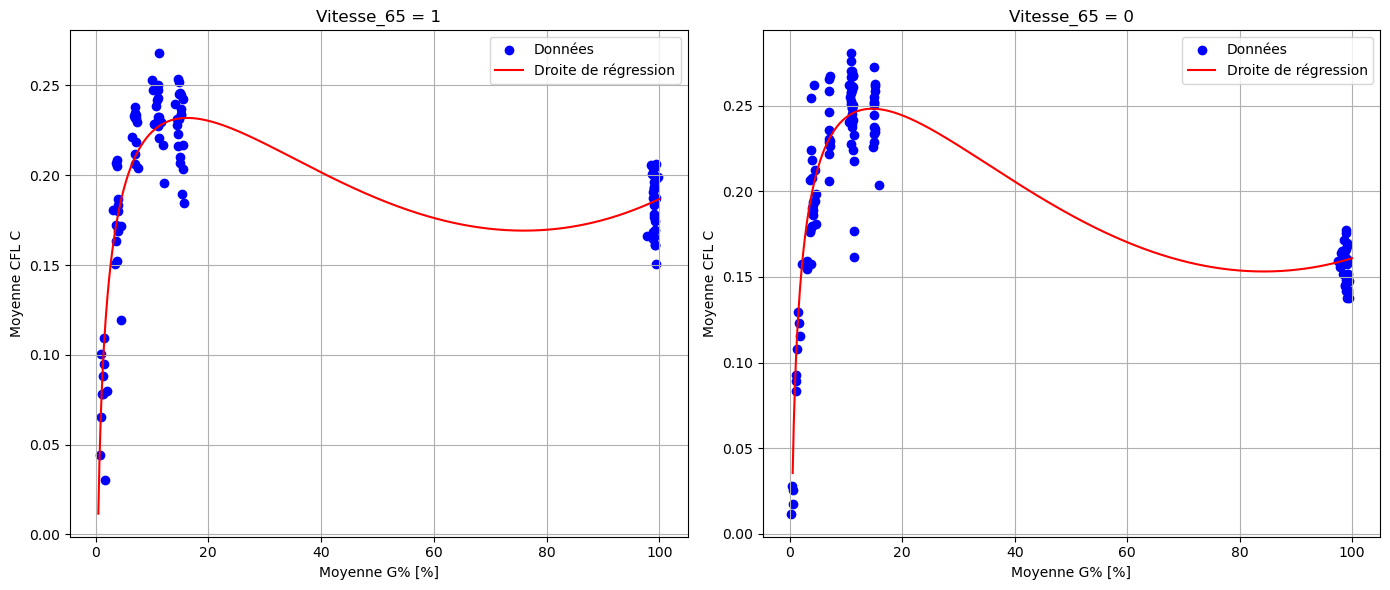

In [33]:
# Coefficients de la régression
intercept = 0.1024


coefficients = {
    'Moyenne G% [%]': -0.007322,
    'log(g)':0.091357,
    'Vitesse_65': -0.024123,
    'g2': 0.000037,
    'g*V':0.000500
}

# Préparation des données
X = ncc.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 1))

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 0))

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## Verglas (60 observations) ..


In [33]:
def descritisation_verglas(x):
    if x<2:
        return "2"
    if x<5:
        return "5"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 17:
        return "17"
    else:
        return "more"

In [73]:
X = ver.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_verglas)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**(2) # valeur recommandé -0.2

X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']


stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y= ver['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=stratify_combined, random_state=74)#24 42 74
regressor = LinearRegression()
regressor.fit(X_train, y_train)
        
        
coef(X, regressor)


Pour le test: RMSE = 0.02018, R² = 75.03, MAE = 0.01692
Pour le train: RMSE = 0.01835, R² = 74.85, MAE = 0.0146
          Feature Coefficient
0  Moyenne G% [%]   -0.002718
1          log(g)    0.047679
2      Vitesse_65    0.005114
3              g2    0.000014
4             g*V   -0.000171
Intercept: 0.0512


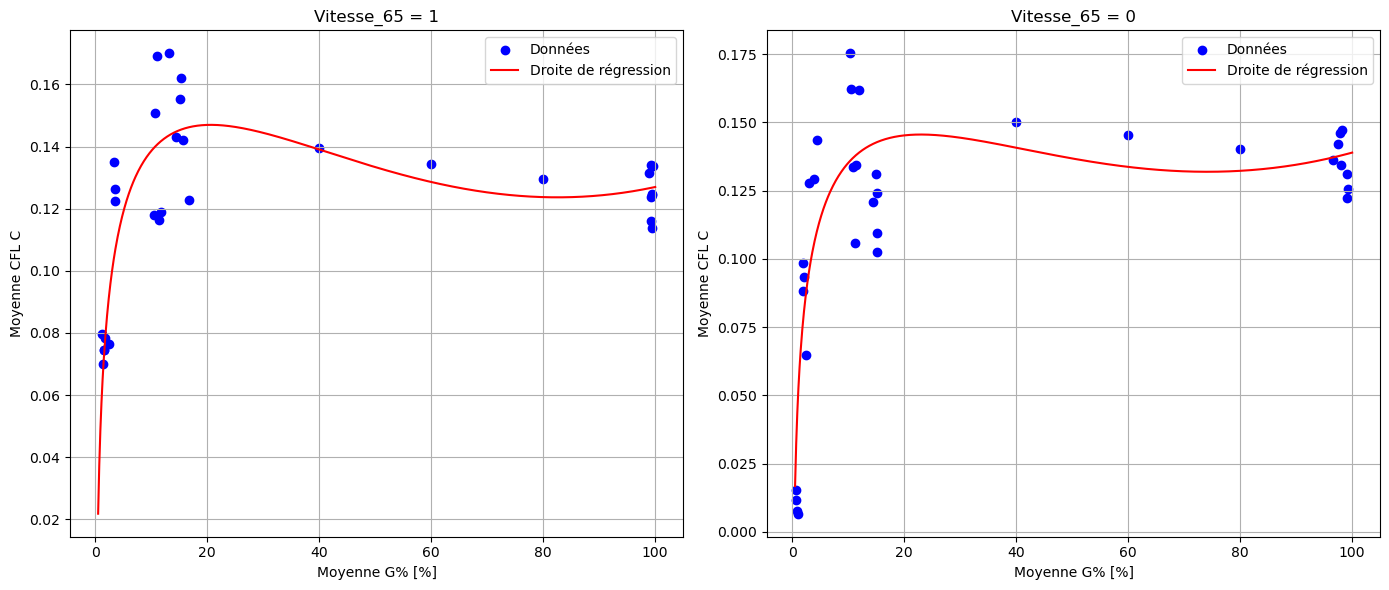

In [34]:
# Coefficients de la régression
intercept = 0.0512
coefficients = {
    'Moyenne G% [%]': -0.002718,
    'log(g)': 0.047679,
    'Vitesse_65': 0.005114,
    'g2': 0.000014,
    'g*V': -0.000171
}

# Préparation des données
X = ver.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 1))

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 0))

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## Glace (122 observations)

Ici contrairement aux précedent contaminant, on a une variabilité significative de la température de bande de roulement.

In [35]:
def descritisation_glace(x):
    if x<3:
        return "3"
    if x<4:
        return "4"
    if x<6:
        return "6"
    if x<8:
        return "8"
    if x<11:
        return "11"
    elif x< 13:
        return "13"
    elif x< 15:
        return "15"
    elif x< 17:
        return "17"
    else:
        return "more"

In [36]:
X = gla.drop(['Moyenne CFL C'], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_glace)

X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
#X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']



stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)
y= gla['Moyenne CFL C']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=40)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.01235, R² = 86.79, MAE = 0.0103
Pour le train: RMSE = 0.01336, R² = 85.25, MAE = 0.01109
          Feature Coefficient
0  Moyenne G% [%]   -0.001375
1      T° BDR (C)    0.009988
2          log(g)    0.035759
3      Vitesse_65    0.015328
4              g2    0.000003
Intercept: -0.0590


#### Remarque T° BDR (C) (normalisation ameliore le modele) !!!!!!!!!!!!!!!!!

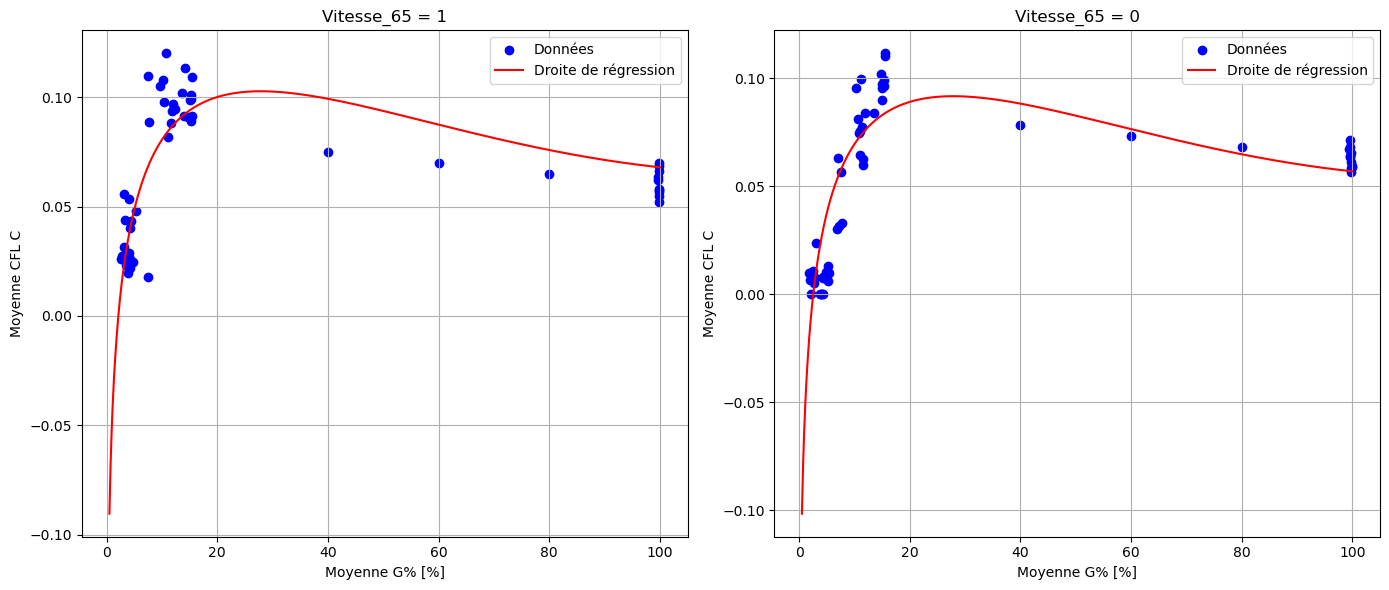

In [46]:
# Coefficients de la régression
intercept = -0.0543
coefficients = {
    'Moyenne G% [%]': -0.002932,
    'log(g)': 0.066109,
    'Vitesse_65': 0.011111,
    'g2': 0.000010,
    # 'g*V': -0.000173
}

# Préparation des données
X = gla.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 )

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 )

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## SLUSH (85 observations)

In [48]:
def descritisation_slh(x):
    if x<0.5:
        return "0.5"
    if x<1:
        return "1"
    if x<4:
        return "4"

    elif x< 14:
        return "14"
    else:
        return "more"


In [49]:
X = slh.drop(['Moyenne CFL C',"T° BDR (C)"], axis=1)
a = X['Moyenne G% [%]'].apply(descritisation_slh)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X,0)

X["g2"] = X['Moyenne G% [%]']**2
X["g*V"] = X['Moyenne G% [%]']*X['Vitesse_65']


stratify_vitesse = X['Vitesse_65']
stratify_glissement = a

# Créer une nouvelle colonne de stratification combinée
stratify_combined = stratify_vitesse.astype(str) + '_' + stratify_glissement.astype(str)

y= slh['Moyenne CFL C']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify = stratify_combined, random_state=29)#2 16   29   68
regressor = LinearRegression()
regressor.fit(X_train, y_train)
    
    
coef(X, regressor)

Pour le test: RMSE = 0.0143, R² = 95.51, MAE = 0.01176
Pour le train: RMSE = 0.02462, R² = 88.94, MAE = 0.01911
          Feature Coefficient
0  Moyenne G% [%]    0.003098
1          log(g)    0.018139
2      Vitesse_65   -0.015013
3              g2   -0.000025
4             g*V   -0.000527
Intercept: 0.0372


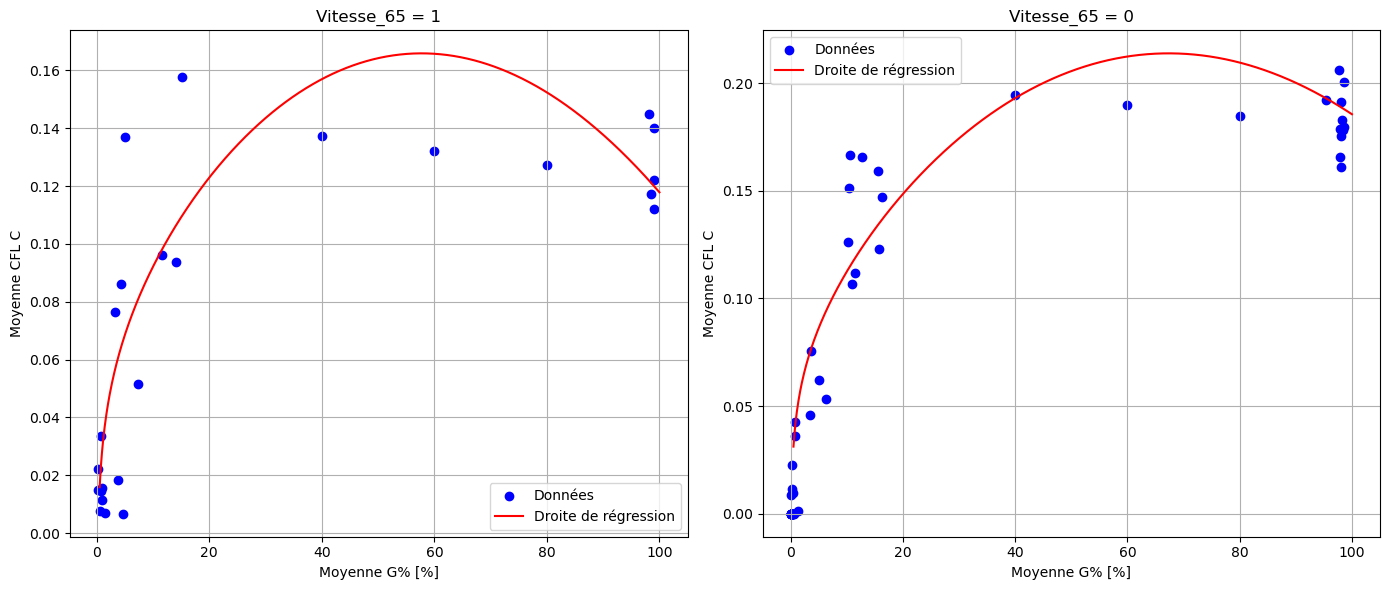

In [56]:
# Coefficients de la régression
intercept = 0.0422
coefficients = {
    'Moyenne G% [%]': 0.003098,
    'log(g)': 0.018139,
    'Vitesse_65': -0.015013,
    'g2': -0.000025,
    'g*V': -0.000527
}

# Préparation des données
X = slh.drop(["T° BDR (C)"], axis=1)
X["log(g)"] = np.log(X['Moyenne G% [%]'])
X = scale_encode(X, 0)
X["g2"] = X['Moyenne G% [%]'] ** 2
X["g*V"] = X['Moyenne G% [%]'] * X['Vitesse_65']
X_v1 = X[X['Vitesse_65'] == 1].drop(['Moyenne CFL C'], axis=1)
X_v0 = X[X['Vitesse_65'] == 0].drop(['Moyenne CFL C'], axis=1)

y_v1 = X[X['Vitesse_65'] == 1]['Moyenne CFL C']
y_v0 = X[X['Vitesse_65'] == 0]['Moyenne CFL C']

# Calcul de la droite de régression pour Vitesse_65 = 1
x = np.linspace(0.5, 100, 1000)
y_v1_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 1 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 1))

# Calcul de la droite de régression pour Vitesse_65 = 0
y_v0_regression = (intercept +
                   coefficients['Moyenne G% [%]'] * x +
                   coefficients['log(g)'] * np.log(x) +
                   coefficients['Vitesse_65'] * 0 +
                   coefficients['g2'] * x**2 +
                   coefficients['g*V'] * (x * 0))

# Tracé des graphes
plt.figure(figsize=(14, 6))

# Graphique pour Vitesse_65 = 1
plt.subplot(1, 2, 1)
plt.scatter(X_v1['Moyenne G% [%]'], y_v1, color='blue', label='Données')
plt.plot(x, y_v1_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 1')
plt.legend()
plt.grid()

# Graphique pour Vitesse_65 = 0
plt.subplot(1, 2, 2)
plt.scatter(X_v0['Moyenne G% [%]'], y_v0, color='blue', label='Données')
plt.plot(x, y_v0_regression, color='red', label='Droite de régression')
plt.xlabel('Moyenne G% [%]')
plt.ylabel('Moyenne CFL C')
plt.title('Vitesse_65 = 0')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


# Fin modelisation lineaire

## Remarque

En raison de l'absence de données dans l'intervalle de 20 à 100 (aucune observation disponible dans cet intervalle), le modèle de régression fonctionne bien là où des données sont présentes, mais il produit des résultats erronés dans l'intervalle de 20 à 100. En réalité, il devrait montrer un plateau ou une courbe faiblement décroissante. Pour imposer ce plateau, nous allons créer des observations artificielles à trois positions (50, 60, 80, 90) pour chaque contaminant et chaque vitesse. L'ajout de ces observations n'est pas aléatoire, étant donné que nous disposons d'observations au glissement 100 et que la courbe après 20 est faiblement décroissante. 

Les valeurs de CFL sont proches de la valeur maximale de glissement et doivent être très proches mais légèrement supérieures. Ainsi, pour le glissement 90, nous ajoutons la valeur médiane des CFL pour le glissement consigné 100 + 0,0025; pour 80, la valeur médiane des CFL pour le glissement consigné 100 + 0,005; pour 60, la valeur médiane des CFL pour le glissement consigné 100 + 0,01, pour et pour 50 la valeur médiane des CFL pour le glissement consigné 100 + 0,0125
 
Nous avons ajouté 64 observations à notre ensemble de données, ce qui représente 6% de la base de données initiale, afin de ne pas altérer la réalité du modèle tout en indiquant qu'il doit y avoir un plateau dans l'intervalle de 20 à 100. Le modèle a bien performé et compris la nécessité d'un plateau. Cependant, il produit un maximum après 20, alors que le maximum devrait se situer parmi nos observations (c'est-à-dire <20). 

Le maximum après 20 s'explique par :

- La tendance croissante des données entre 0 et 20, incitant le modèle à poursuivre cette croissance.
- L'absence de contrainte imposée sur le maximum, seulement sur le plateau.

